# 02 - Exposure

**What this notebook establishes:** a gridded estimate of built-asset value across the
coastal Odisha study domain, aligned cell-for-cell with the hazard grid from `01_hazard`.

**What it hands downstream:** exposure vectors on the 525-cell grid (baseline, and ±30%
variants for sensitivity analysis), saved for use in `03_impact.ipynb`.

---

### Approach

Hazard answers *how severe and how often*. Exposure answers *what is there to be damaged*.

LitPop is used as the exposure proxy. It distributes national asset value across a grid using
nighttime light intensity and population density as the disaggregation weights. This is a
well-documented open method, and for a study region without access to an actual insured
portfolio it is the standard substitute.

The critical requirement is **grid alignment**: exposure must be defined on exactly the same
525 centroids as the hazard, or the impact calculation will silently mismatch assets to wind
speeds. This is enforced by construction rather than by post-hoc matching.

In [1]:
from climada.entity import LitPop

### Population input data

LitPop requires gridded population data (GPW v4) as one of its two disaggregation weights.
The path is checked before proceeding, since a missing input here fails deep inside the
LitPop call with a less obvious error.

In [2]:
from pathlib import Path

gpw_file = Path(
    "../data/"
    "gpw-v4-population-count-rev11_2020_30_sec_tif/"
    "gpw_v4_population_count_rev11_2020_30_sec.tif"
)

print("GPW file exists:", gpw_file.exists())
print("GPW file:", gpw_file)

GPW file exists: True
GPW file: ../data/gpw-v4-population-count-rev11_2020_30_sec_tif/gpw_v4_population_count_rev11_2020_30_sec.tif


In [3]:
project_data = Path("../data")

print("Project data directory:", project_data)

Project data directory: ../data


### Generating national exposure

LitPop is generated at country level first, then clipped. Generating for India as a whole and
subsetting afterwards is more reliable than attempting a region-limited call, since the
disaggregation weights are normalised nationally.

In [4]:
litpop_india = LitPop.from_countries(
    "IND",
    data_dir=project_data,
    reference_year=2020,
    gpw_version=11
)

In [5]:
print(type(litpop_india))

<class 'climada.entity.exposures.litpop.litpop.LitPop'>


In [6]:
print(len(litpop_india.gdf))

4011479


In [7]:
print(litpop_india.gdf.head())

          value  region_id  impf_                  geometry
0      0.000000        356      1   POINT (73.07917 8.3125)
1      0.000000        356      1  POINT (73.07917 8.30417)
2   3567.784595        356      1   POINT (73.07083 8.2875)
3  78342.166221        356      1  POINT (73.02917 8.27083)
4  37113.089803        356      1  POINT (73.05417 8.27083)


## Spatial filtering and data quality checks

The raw LitPop output covers all of India. Reducing it to the study domain requires two
distinct operations, which are deliberately kept separate:

1. **Bounding-box clip** - a fast rectangular subset to the study coordinates
2. **Land masking** - removing points that fall over water

The second step matters. A bounding box over a coastal region necessarily includes ocean, and
exposure assigned to sea cells would be modelled as damageable assets. The checks below
confirm how many points fall outside land and where they sit.

In [8]:
odisha_bbox = litpop_india.gdf.cx[82:88, 17:22]

print("Points in modelling domain:", len(odisha_bbox))
print("Total LitPop value:", odisha_bbox["value"].sum())

Points in modelling domain: 238571
Total LitPop value: 231621754793.41266


In [9]:
print(litpop_india.gdf.columns)

Index(['value', 'region_id', 'impf_', 'geometry'], dtype='object')


In [10]:
print(litpop_india.gdf.crs)

GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [11]:
import cartopy.io.shapereader as shpreader
import geopandas as gpd

land_shp = shpreader.natural_earth(
    resolution="10m",
    category="physical",
    name="land"
)

land = gpd.read_file(land_shp)

print("Land geometries:", len(land))
print("CRS:", land.crs)

Land geometries: 11
CRS: EPSG:4326


In [12]:
odisha_bbox = litpop_india.gdf.cx[82:88, 17:22].copy()

In [13]:
odisha_land = gpd.sjoin(
    odisha_bbox,
    land[["geometry"]],
    how="inner",
    predicate="within"
)

In [14]:
print("LitPop points in box:", len(odisha_bbox))
print("LitPop points on land:", len(odisha_land))
print("Land-only LitPop value:", odisha_land["value"].sum())

LitPop points in box: 238571
LitPop points on land: 238571
Land-only LitPop value: 231621754793.41266


In [15]:
print("Land bounds:", land.total_bounds)

Land bounds: [-180.          -90.          180.           83.63410065]


In [16]:
test_point = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([86], [17]),
    crs="EPSG:4326"
)

result = gpd.sjoin(
    test_point,
    land[["geometry"]],
    how="left",
    predicate="within"
)

print(result[["geometry", "index_right"]])

        geometry  index_right
0  POINT (86 17)          NaN


### Boundary inspection

These checks examine the edges of the domain, particularly the southern boundary and the
near-shore band, to confirm that the land mask is behaving as intended and that no
significant asset value is being assigned offshore or discarded onshore.

In [17]:
print("Lat range:", odisha_bbox.geometry.y.min(), odisha_bbox.geometry.y.max())
print("Lon range:", odisha_bbox.geometry.x.min(), odisha_bbox.geometry.x.max())

Lat range: 17.00416667 21.99583333
Lon range: 82.00416667 87.99583333


In [18]:
near_ocean = odisha_bbox.cx[85.5:86.5, 16.5:17.5]

print("Points near 86E, 17N:", len(near_ocean))

if len(near_ocean) > 0:
    print(near_ocean[["value", "geometry"]].head())

Points near 86E, 17N: 0


In [19]:
edge = odisha_bbox.cx[85.5:86.5, 17.0:17.1]

print("Points:", len(edge))

if len(edge) > 0:
    print(edge[["value", "geometry"]].head())

Points: 0


In [20]:
print("Total points:", len(odisha_bbox))
print("Zero-value points:", (odisha_bbox["value"] == 0).sum())
print(
    "Non-zero points:",
    (odisha_bbox["value"] > 0).sum()
)

Total points: 238571
Zero-value points: 415
Non-zero points: 238156


In [21]:
odisha_bbox["lat"] = odisha_bbox.geometry.y
odisha_bbox["lon"] = odisha_bbox.geometry.x

print(
    odisha_bbox.sort_values("lat")[
        ["value", "lat", "lon"]
    ].head(10)
)

                value        lat        lon
3383854  1.630737e+06  17.004167  82.287500
3383853  2.873913e+07  17.004167  82.279167
3383852  3.264062e+07  17.004167  82.270833
3383850  3.213051e+07  17.004167  82.254167
3383839  3.558922e+06  17.004167  82.162500
3383840  3.919428e+06  17.004167  82.170833
3383841  4.340018e+06  17.004167  82.179167
3383842  5.464452e+06  17.004167  82.187500
3383843  8.689348e+06  17.004167  82.195833
3383844  1.664148e+07  17.004167  82.204167


In [22]:
print(
    odisha_bbox.sort_values("lat")[
        ["value", "lat", "lon"]
    ].tail(10)
)

                value        lat        lon
2447414  3.302461e+06  21.995833  82.379167
2447413  3.094315e+06  21.995833  82.370833
2447412  3.978337e+06  21.995833  82.362500
2447411  4.643154e+06  21.995833  82.354167
2447410  3.907673e+06  21.995833  82.345833
2447409  3.685584e+06  21.995833  82.337500
2447408  3.225791e+06  21.995833  82.329167
2447407  3.006291e+06  21.995833  82.320833
2447375  4.196064e+06  21.995833  82.054167
2447404  4.124886e+06  21.995833  82.295833


### Administrative boundary clip

Natural Earth admin-1 boundaries are used to restrict exposure to Odisha state proper, rather
than relying on the rectangular box alone. This removes value belonging to neighbouring
states that falls inside the bounding box.

In [23]:
admin1_shp = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_1_states_provinces"
)

print(admin1_shp)

/home/navneet/.local/share/cartopy/shapefiles/natural_earth/cultural/ne_10m_admin_1_states_provinces.shp


In [24]:
admin1 = gpd.read_file(admin1_shp)

print(admin1.columns)
print(admin1[["name", "admin"]].head())

Index(['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2',
       'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt',
       ...
       'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT', 'FCLASS_NL',
       'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'FCLASS_TLC', 'geometry'],
      dtype='object', length=122)
                 name      admin
0          Entre Ríos  Argentina
1            Paysandú    Uruguay
2    Kalimantan Timur  Indonesia
3               Sabah   Malaysia
4  Arica y Parinacota      Chile


In [25]:
odisha_boundary = admin1[
    (admin1["admin"] == "India") &
    (admin1["name"] == "Odisha")
].copy()

print("Number of Odisha polygons:", len(odisha_boundary))
print("CRS:", odisha_boundary.crs)
print("Bounds:", odisha_boundary.total_bounds)

Number of Odisha polygons: 1
CRS: EPSG:4326
Bounds: [81.39072228 17.78723501 87.47738691 22.55673717]


In [26]:
odisha_litpop = gpd.sjoin(
    litpop_india.gdf,
    odisha_boundary[["geometry"]],
    how="inner",
    predicate="within"
).copy()

In [27]:
print("Odisha LitPop points:", len(odisha_litpop))
print("Total Odisha LitPop value:", odisha_litpop["value"].sum())

Odisha LitPop points: 193548
Total Odisha LitPop value: 162012218309.3282


In [28]:
print(
    "Min/Max longitude:",
    odisha_litpop.geometry.x.min(),
    odisha_litpop.geometry.x.max()
)

print(
    "Min/Max latitude:",
    odisha_litpop.geometry.y.min(),
    odisha_litpop.geometry.y.max()
)

Min/Max longitude: 81.39583333 87.47083333
Min/Max latitude: 17.7875 22.55416667


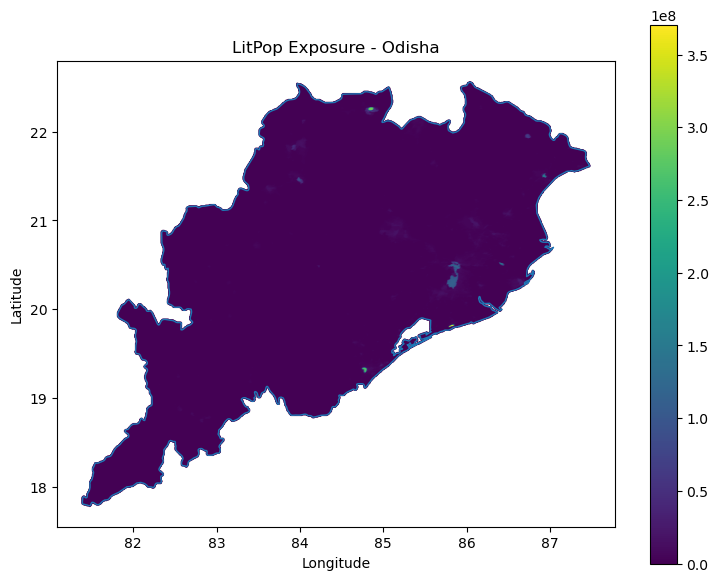

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

odisha_boundary.boundary.plot(
    ax=ax,
    linewidth=1
)

odisha_litpop.plot(
    ax=ax,
    column="value",
    markersize=1,
    legend=True
)

ax.set_title("LitPop Exposure - Odisha")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

## Exposure data quality assessment

Standard data-quality checks before the exposure set is used: null values, distributional
summary, and inspection of the largest values.

The largest-value check is the most informative. If the top-valued cells do not correspond to
known urban centres, the disaggregation has gone wrong somewhere.

In [30]:
print("Null values:", odisha_litpop["value"].isna().sum())
print("Zero values:", (odisha_litpop["value"] == 0).sum())
print("Negative values:", (odisha_litpop["value"] < 0).sum())

print(
    "Duplicate coordinates:",
    odisha_litpop.duplicated(
        subset=["geometry"]
    ).sum()
)

Null values: 0
Zero values: 395
Negative values: 0
Duplicate coordinates: 0


In [31]:
print(odisha_litpop["value"].describe())

count    1.935480e+05
mean     8.370648e+05
std      6.927909e+06
min      0.000000e+00
25%      8.944203e+03
50%      2.038844e+04
75%      1.452373e+05
max      3.706414e+08
Name: value, dtype: float64


In [32]:
top10 = odisha_litpop.nlargest(10, "value")

print(
    top10[["value", "geometry"]].to_string(index=False)
)

       value                  geometry
3.706414e+08 POINT (85.82917 19.80417)
3.706414e+08  POINT (85.8375 19.80417)
3.681274e+08 POINT (85.80417 19.79583)
3.617194e+08  POINT (85.8125 19.79583)
3.565120e+08 POINT (85.82083 19.80417)
3.007647e+08 POINT (85.84583 19.80417)
2.903158e+08  POINT (84.84583 22.2375)
2.903158e+08   POINT (84.8625 22.2375)
2.903158e+08  POINT (84.85417 22.2375)
2.903158e+08  POINT (84.87083 22.2375)


In [33]:
total_exposure = odisha_litpop["value"].sum()

for q in [0.90, 0.95, 0.99, 0.999]:
    threshold = odisha_litpop["value"].quantile(q)
    value_above = odisha_litpop.loc[
        odisha_litpop["value"] >= threshold, "value"
    ].sum()

    print(
        f"Top {(1-q)*100:.1f}% of cells: "
        f"{value_above / total_exposure * 100:.2f}% of total exposure"
    )

Top 10.0% of cells: 88.79% of total exposure
Top 5.0% of cells: 76.88% of total exposure
Top 1.0% of cells: 51.08% of total exposure
Top 0.1% of cells: 19.70% of total exposure


Exposure concentration: LitPop exposure is strongly spatially concentrated. The highest-value 1% of cells accounts for approximately 51% of total modeled exposure, while the highest 0.1% accounts for approximately 20%. This concentration is consistent with the population/nightlight-based construction of LitPop and the concentration of economic activity in urban and industrial areas. However, it means aggregate loss estimates may be particularly sensitive to the treatment of high-exposure locations.

## Aligning exposure to the hazard grid

This is the step that guarantees hazard and exposure correspond. LitPop points are aggregated
onto the same 0.25° grid used for the hazard centroids, producing a complete 525-element
exposure vector - including explicit zeros for cells with no assigned value.

Constructing a full-length vector rather than an inner join is deliberate: it ensures the
exposure array and the hazard intensity matrix have compatible dimensions by construction, so
a misalignment would surface as an immediate error rather than as silently misattributed
losses.

In [34]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

lons = np.linspace(82, 88, 25)
lats = np.linspace(17, 22, 21)

geometry = [
    Point(lon, lat)
    for lat in lats
    for lon in lons
]

centroids_odisha = gpd.GeoDataFrame(
    geometry=geometry,
    crs="EPSG:4326"
)

print("Number of centroids:", len(centroids_odisha))
print(centroids_odisha.head())

Number of centroids: 525
           geometry
0     POINT (82 17)
1  POINT (82.25 17)
2   POINT (82.5 17)
3  POINT (82.75 17)
4     POINT (83 17)


In [35]:
print(len(centroids_odisha))
print(centroids_odisha.geometry.iloc[0])
print(centroids_odisha.geometry.iloc[-1])

525
POINT (82 17)
POINT (88 22)


In [36]:
print("Unique longitude spacing:",
      np.unique(np.diff(sorted(centroids_odisha.geometry.x.unique()))))

print("Unique latitude spacing:",
      np.unique(np.diff(sorted(centroids_odisha.geometry.y.unique()))))

Unique longitude spacing: [0.25]
Unique latitude spacing: [0.25]


In [37]:
# Make a working copy
exp = odisha_litpop.copy()

# Assign each LitPop point to nearest 0.25-degree centroid
exp["lon_idx"] = np.round(
    (exp.geometry.x - 82) / 0.25
).astype(int)

exp["lat_idx"] = np.round(
    (exp.geometry.y - 17) / 0.25
).astype(int)

# Keep only cells represented by our 525-centroid grid
exp = exp[
    exp["lon_idx"].between(0, 24) &
    exp["lat_idx"].between(0, 20)
].copy()

print("LitPop points assigned:", len(exp))

LitPop points assigned: 182308


In [38]:
exposure_grid = (
    exp.groupby(["lat_idx", "lon_idx"])["value"]
    .sum()
    .reset_index()
)

print("Grid cells with exposure:", len(exposure_grid))
print("Aggregated exposure:", exposure_grid["value"].sum())

Grid cells with exposure: 244
Aggregated exposure: 147682902406.22885


In [39]:
print(
    "Original Odisha exposure:",
    odisha_litpop["value"].sum()
)

print(
    "Aggregated exposure:",
    exposure_grid["value"].sum()
)

print(
    "Difference:",
    odisha_litpop["value"].sum()
    - exposure_grid["value"].sum()
)

Original Odisha exposure: 162012218309.3282
Aggregated exposure: 147682902406.22885
Difference: 14329315903.099335


In [40]:
from shapely.geometry import Polygon

### Domain coverage check

Confirms which parts of Odisha fall inside the hazard domain, including an explicit check on
Balasore - a coastal, cyclone-exposed district near the northern boundary of the grid. Coastal
districts falling outside the domain would be a material omission; inland districts falling
outside it are an intended consequence of the coastal scoping decision.

In [41]:
# Check the Odisha boundary relative to our hazard domain
hazard_box = Polygon([
    (82, 17),
    (88, 17),
    (88, 22),
    (82, 22),
    (82, 17)
])

hazard_box_gdf = gpd.GeoDataFrame(
    geometry=[hazard_box],
    crs="EPSG:4326"
)

study_land = gpd.overlay(
    odisha_boundary,
    hazard_box_gdf,
    how="intersection"
)

print("Odisha within hazard domain:")
print(study_land.total_bounds)

Odisha within hazard domain:
[82.         17.99293305 87.47738691 22.        ]


In [42]:
balasore = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([86.93], [21.49]),
    crs="EPSG:4326"
)

result = gpd.sjoin(
    balasore,
    study_land[["geometry"]],
    how="left",
    predicate="within"
)

print(result[["geometry", "index_right"]])

              geometry  index_right
0  POINT (86.93 21.49)            0


In [43]:
exposure_study = gpd.sjoin(
    litpop_india.gdf,
    study_land[["geometry"]],
    how="inner",
    predicate="within"
).copy()

print("Study-area LitPop points:", len(exposure_study))
print("Study-area exposure:", exposure_study["value"].sum())

Study-area LitPop points: 175150
Study-area exposure: 144858095456.26517


In [44]:
exposure_study["lon_idx"] = np.round(
    (exposure_study.geometry.x - 82) / 0.25
).astype(int)

exposure_study["lat_idx"] = np.round(
    (exposure_study.geometry.y - 17) / 0.25
).astype(int)

In [45]:
print(
    "Outside longitude range:",
    (~exposure_study["lon_idx"].between(0, 24)).sum()
)

print(
    "Outside latitude range:",
    (~exposure_study["lat_idx"].between(0, 20)).sum()
)

Outside longitude range: 0
Outside latitude range: 0


In [46]:
exposure_grid = (
    exposure_study
    .groupby(["lat_idx", "lon_idx"])["value"]
    .sum()
    .reset_index()
)

print("Grid cells with exposure:", len(exposure_grid))
print("Aggregated exposure:", exposure_grid["value"].sum())

Grid cells with exposure: 244
Aggregated exposure: 144858095456.2652


### Value conservation check

Compares total exposure before and after regridding. Aggregating points onto a coarser grid
should redistribute value, not create or destroy it, so the totals should match closely.

In [47]:
original_total = exposure_study["value"].sum()
aggregated_total = exposure_grid["value"].sum()

print("Original study-area exposure:", original_total)
print("Aggregated exposure:", aggregated_total)
print("Difference:", original_total - aggregated_total)

Original study-area exposure: 144858095456.26517
Aggregated exposure: 144858095456.2652
Difference: -3.0517578125e-05


In [48]:
# Create a complete 525-cell exposure vector
exposure_grid["centroid_idx"] = (
    exposure_grid["lat_idx"] * 25
    + exposure_grid["lon_idx"]
)

exposure_values = np.zeros(525)

exposure_values[
    exposure_grid["centroid_idx"].astype(int)
] = exposure_grid["value"].values

print("Exposure cells:", len(exposure_values))
print("Non-zero cells:", np.count_nonzero(exposure_values))
print("Total exposure:", exposure_values.sum())

Exposure cells: 525
Non-zero cells: 244
Total exposure: 144858095456.26517


In [49]:
centroids_odisha["value"] = exposure_values

In [50]:
print(centroids_odisha[["geometry", "value"]].head())
print("Total:", centroids_odisha["value"].sum())

           geometry  value
0     POINT (82 17)    0.0
1  POINT (82.25 17)    0.0
2   POINT (82.5 17)    0.0
3  POINT (82.75 17)    0.0
4     POINT (83 17)    0.0
Total: 144858095456.26517


## Sensitivity variants

Because exposure is a proxy rather than a measured portfolio, its absolute level is uncertain.
Two scaled variants (±30%) are constructed here so that `03_impact.ipynb` can quantify how
exposure uncertainty propagates into loss and pricing, without re-deriving the exposure set.

In [51]:
exposure_baseline = centroids_odisha["value"].copy()

exposure_low = exposure_baseline * 0.70
exposure_high = exposure_baseline * 1.30

print("Baseline:", exposure_baseline.sum())
print("Low (-30%):", exposure_low.sum())
print("High (+30%):", exposure_high.sum())

Baseline: 144858095456.26517
Low (-30%): 101400666819.38562
High (+30%): 188315524093.1447


In [52]:
exposure_baseline_gdf = centroids_odisha.copy()
exposure_low_gdf = centroids_odisha.copy()
exposure_high_gdf = centroids_odisha.copy()

exposure_baseline_gdf["value"] = exposure_baseline
exposure_low_gdf["value"] = exposure_low
exposure_high_gdf["value"] = exposure_high

## Persisting exposure

Exposure vectors are serialised for downstream use.

In [53]:
output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

In [54]:
import pickle

with open(output_dir / "exposure_baseline.pkl", "wb") as f:
    pickle.dump(exposure_baseline_gdf, f)

with open(output_dir / "exposure_low.pkl", "wb") as f:
    pickle.dump(exposure_low_gdf, f)

with open(output_dir / "exposure_high.pkl", "wb") as f:
    pickle.dump(exposure_high_gdf, f)

In [55]:
centroids_odisha.to_file(
    output_dir / "odisha_exposure_grid.gpkg",
    layer="exposure_grid",
    driver="GPKG"
)

In [56]:
print(list(output_dir.glob("*")))

[PosixPath('../outputs/figures'), PosixPath('../outputs/exposure_baseline.pkl'), PosixPath('../outputs/exposure_low.pkl'), PosixPath('../outputs/.ipynb_checkpoints'), PosixPath('../outputs/odisha_exposure_grid.gpkg'), PosixPath('../outputs/hazard_odisha_50.pkl'), PosixPath('../outputs/aal_by_centroid.gpkg'), PosixPath('../outputs/exposure_high.pkl'), PosixPath('../outputs/north_indian_ocean_tracks.png')]


Exposure limitations: LitPop provides a proxy for spatially distributed economic asset exposure derived primarily from population and night-time light information. It may under-represent informal and low-light coastal settlements, which are particularly relevant to cyclone vulnerability in Odisha. It also does not comprehensively represent sector-specific assets such as agricultural and fishing assets. Furthermore, LitPop represents economic exposure rather than insured exposure; therefore, losses estimated from this layer should be interpreted as modeled economic losses rather than insured losses. The difference between total economic exposure and insured exposure represents an important component of the insurance protection gap.

Study-domain limitation: Exposure is restricted to the portion of Odisha within the validated hazard domain (82–88°E, 17–22°N). Major coastal areas including Balasore are included, but portions of Odisha outside this domain are intentionally excluded.

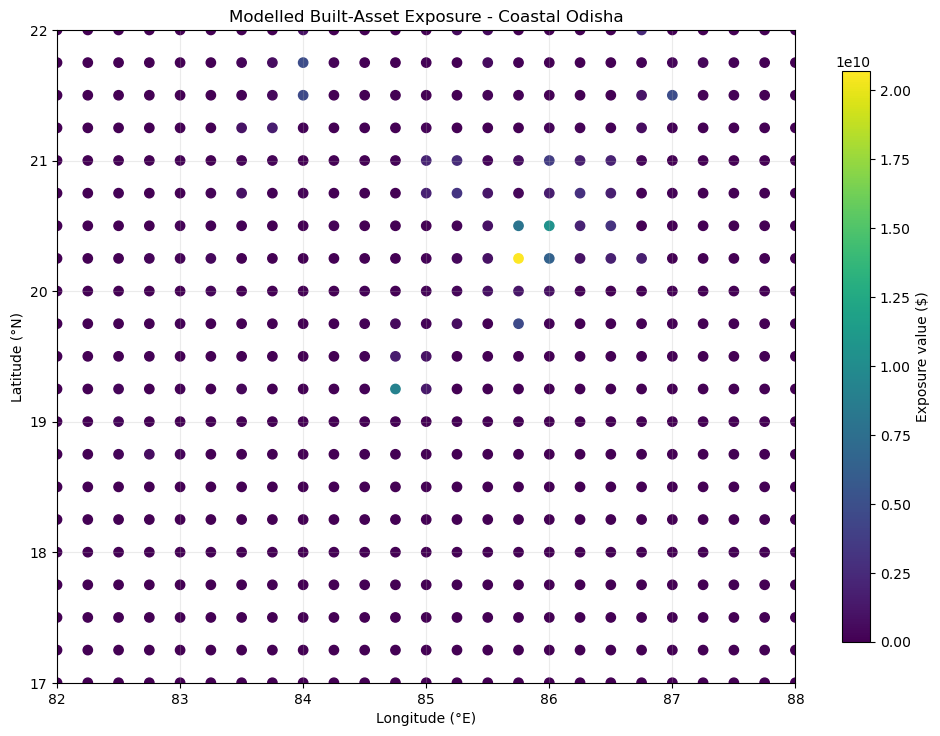

In [57]:
import matplotlib.pyplot as plt

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot baseline exposure
exposure_baseline_gdf.plot(
    ax=ax,
    column="value",
    cmap="viridis",
    markersize=45,
    legend=True,
    legend_kwds={
        "label": "Exposure value ($)",
        "shrink": 0.75
    }
)

ax.set_xlim(82, 88)
ax.set_ylim(17, 22)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Modelled Built-Asset Exposure - Coastal Odisha")

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    figures_dir / "exposure_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

## Exposure stage conclusion

**What was built.** LitPop-derived built-asset exposure for the coastal Odisha belt,
aggregated onto the identical 525-cell grid used by the hazard module, with a total modelled
exposure of **$144.86B**, plus ±30% variants for sensitivity testing.

**What was checked.** Null values, value distribution, largest-value cells against known urban
centres, land masking against Natural Earth geometry, administrative boundary containment,
coastal district coverage including Balasore, and value conservation through regridding.

**Known limitations carried forward.**

- LitPop is a **proxy for built-asset value**, not an insured portfolio. It carries no policy
  terms, deductibles or limits, so downstream results represent economic rather than insured
  loss.
- Disaggregation by nighttime lights and population may **under-represent informal coastal
  settlements**, which typically emit little light while being highly vulnerable a
  systematic bias specific to this coastline.
- **Agricultural and fishing-sector assets are not represented**, despite being economically
  material in this region.
- Exposure is restricted to the portion of Odisha inside the validated hazard domain, so
  totals are **not** state-wide figures.

**Output:** exposure vectors → consumed by `03_impact.ipynb`.

In [58]:
print("value_unit :", litpop_india.value_unit)
print("fin_mode   :", litpop_india.fin_mode)
print("India total:", f"{litpop_india.gdf['value'].sum():,.0f}")

value_unit : USD
fin_mode   : pc
India total: 6,769,001,375,609
